### Basics of Neural Networks
 * Build, train, and evaluate NNs with torch
 * Key elements of NNs
   1. Model backbone - Feature extraction, different model types (FNN, CNN, RNN, etc.)
   2. Model head - Output layer + loss function, different learning paradigms (SL, USL, RL)
* NNs discussed in Part 1
   1. FNN for numerical data regression
   2. FNN for categorical data classification
   3. (Advanced) Density network for probabilistic regression
* Problems:
   1. Regression: from sklearn.datasets import fetch_california_housing
   2. Classification: from sklearn.datasets import load_breast_cancer

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 FNN for Tabular Data
 * Numerical data regression
 * Categorical data classification

##### 1.1 FNN for numerical data regression

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and preprocess the data
data = fetch_california_housing()
X = data.data
y = data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

Epoch 10/100, Train Loss: 5.3136, Val Loss: 5.1371
Epoch 20/100, Train Loss: 4.5565, Val Loss: 4.3687
Epoch 30/100, Train Loss: 3.6123, Val Loss: 3.4026
Epoch 40/100, Train Loss: 2.6044, Val Loss: 2.4066
Epoch 50/100, Train Loss: 1.7993, Val Loss: 1.6568
Epoch 60/100, Train Loss: 1.3309, Val Loss: 1.2596
Epoch 70/100, Train Loss: 1.0818, Val Loss: 1.0555
Epoch 80/100, Train Loss: 0.9194, Val Loss: 0.9101
Epoch 90/100, Train Loss: 0.8323, Val Loss: 0.8287
Epoch 100/100, Train Loss: 0.7830, Val Loss: 0.7845
Test MSE: 0.7845


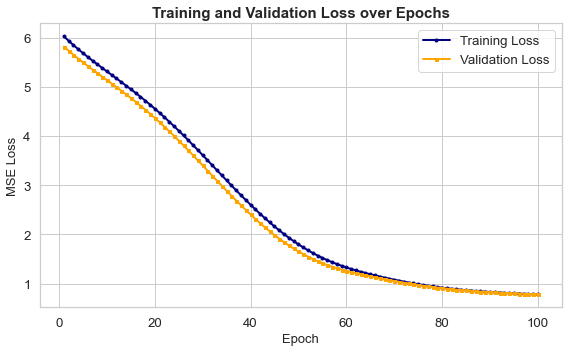

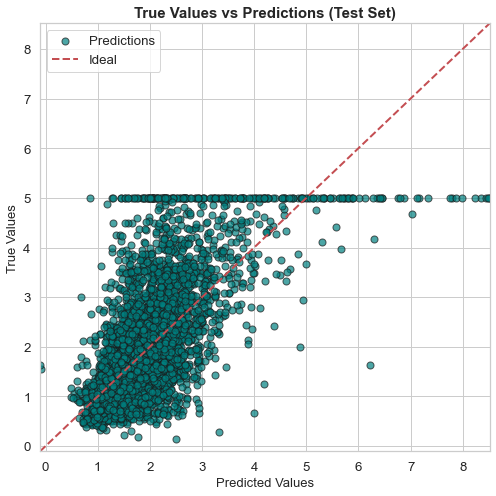

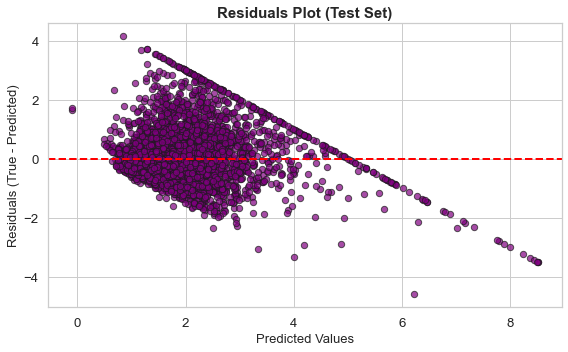

In [3]:
# 2. Define the feedforward neural network
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            # Output layer is a single neuron for regression
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = FeedforwardNN(input_dim)

# 3. Set up loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training loop with loss tracking (now includes validation loss)
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    # Training step
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation step
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# 5. Evaluation on test set
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)
    print(f"Test MSE: {test_loss.item():.4f}")

# --- Professional Figures for Performance ---

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# Plot 1: Training and Validation Loss Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, color='navy', linewidth=2, marker='o', markersize=3, label='Training Loss')
plt.plot(range(1, epochs+1), val_losses, color='orange', linewidth=2, marker='s', markersize=3, label='Validation Loss')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MSE Loss', fontsize=13)
plt.title('Training and Validation Loss over Epochs', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot: True Values vs Predictions (Test Set)
y_true = y_test_tensor.cpu().numpy().flatten()
y_pred = predictions.cpu().numpy().flatten()

plt.figure(figsize=(7,7))
plt.scatter(y_pred, y_true, alpha=0.7, color='teal', edgecolors='k', s=50, label='Predictions')
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('Predicted Values', fontsize=13)
plt.ylabel('True Values', fontsize=13)
plt.title('True Values vs Predictions (Test Set)', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Residuals Plot
residuals = y_true - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.7, color='purple', edgecolors='k', s=40)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values', fontsize=13)
plt.ylabel('Residuals (True - Predicted)', fontsize=13)
plt.title('Residuals Plot (Test Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1.2 FNN for categorical data classification

In [4]:
# Feedforward Neural Network for Breast Cancer Classification

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load and preprocess data
data = load_breast_cancer()
X = data.data
y = data.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


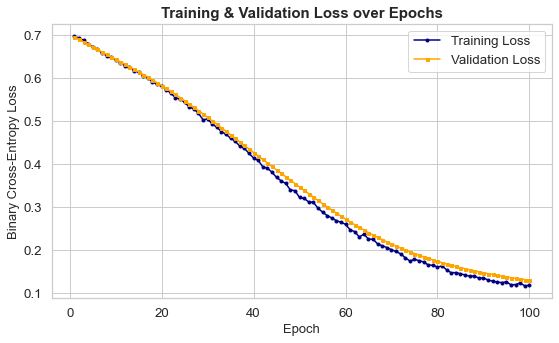

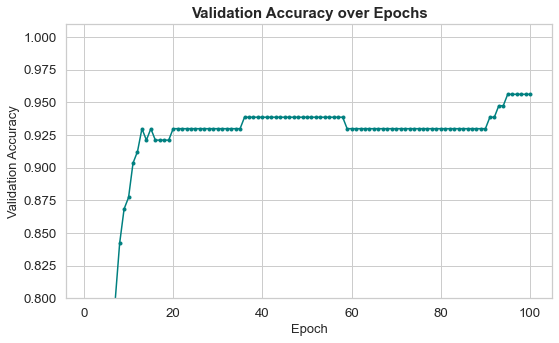

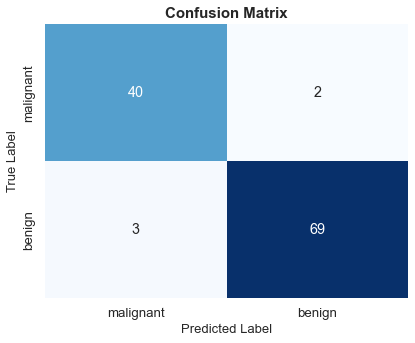

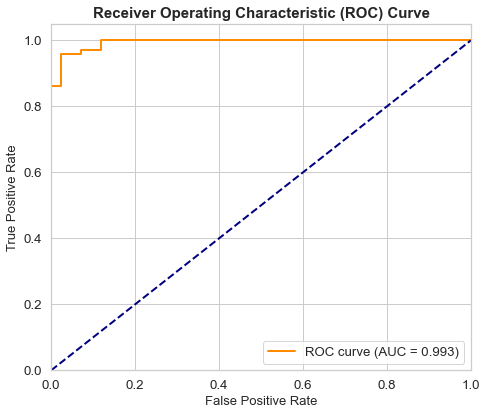

Test Accuracy: 95.61%

Classification Report:
               precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [5]:
# 2. Define the feedforward neural network
class BreastCancerNet(nn.Module):
    def __init__(self, input_dim):
        super(BreastCancerNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            # Output layer is a single neuron with sigmoid activation
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = BreastCancerNet(X_train.shape[1])

# 3. Training setup
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

train_losses = []
val_losses = []
val_accuracies = []

# 4. Training loop
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())
        preds = (val_outputs >= 0.5).float()
        acc = (preds.eq(y_test_tensor)).float().mean().item()
        val_accuracies.append(acc)

# 5. Evaluation
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).cpu().numpy().flatten()
    y_pred = (y_pred_proba >= 0.5).astype(int)
    test_acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=data.target_names)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

# 6. Visualization

sns.set(style="whitegrid", font_scale=1.2)

# Plot 1: Training and Validation Loss
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', color='navy', marker='o', markersize=3)
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', color='orange', marker='s', markersize=3)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=13)
plt.title('Training & Validation Loss over Epochs', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Validation Accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), val_accuracies, color='teal', marker='o', markersize=3)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('Validation Accuracy over Epochs', fontsize=15, fontweight='bold')
plt.ylim(0.8, 1.01)
plt.tight_layout()
plt.show()

# Plot 3: Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 4: ROC Curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Print classification report
print("Test Accuracy: {:.2f}%".format(test_acc * 100))
print("\nClassification Report:\n", report)

##### 1.3 Reconfigure the NN in 1.2
* Treat it as multi-class classification
* Adjust the model head to: Softmax activation function + NLL loss

2
Epoch 1/60 - Train Loss: 0.6706 - Val Loss: 0.6536 - Train Acc: 0.6231 - Val Acc: 0.6353
Epoch 10/60 - Train Loss: 0.5723 - Val Loss: 0.5638 - Train Acc: 0.7337 - Val Acc: 0.7294
Epoch 20/60 - Train Loss: 0.4540 - Val Loss: 0.4548 - Train Acc: 0.8392 - Val Acc: 0.8353
Epoch 30/60 - Train Loss: 0.3290 - Val Loss: 0.3355 - Train Acc: 0.9070 - Val Acc: 0.9059
Epoch 40/60 - Train Loss: 0.2271 - Val Loss: 0.2302 - Train Acc: 0.9322 - Val Acc: 0.9647
Epoch 50/60 - Train Loss: 0.1609 - Val Loss: 0.1569 - Train Acc: 0.9523 - Val Acc: 0.9529
Epoch 60/60 - Train Loss: 0.1213 - Val Loss: 0.1111 - Train Acc: 0.9623 - Val Acc: 0.9765


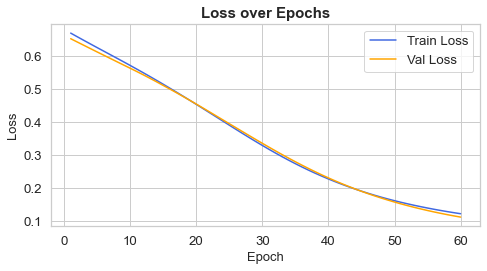

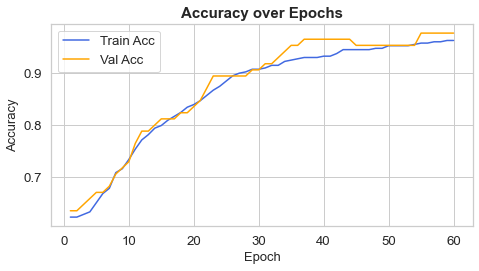

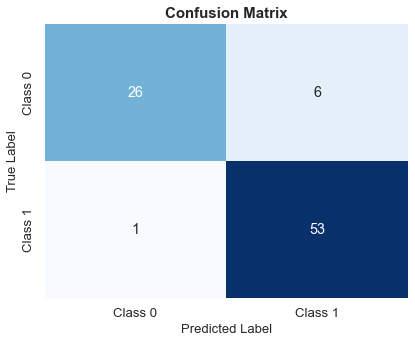

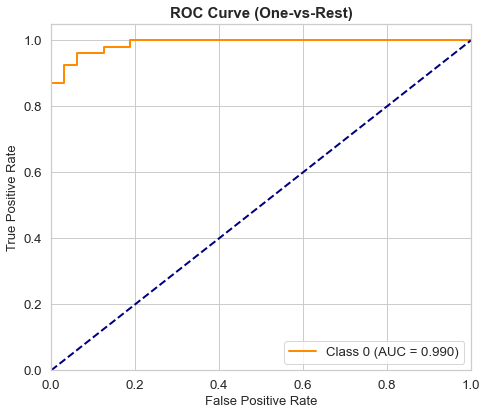

Test Accuracy: 91.86%

Classification Report:
               precision    recall  f1-score   support

     Class 0       0.96      0.81      0.88        32
     Class 1       0.90      0.98      0.94        54

    accuracy                           0.92        86
   macro avg       0.93      0.90      0.91        86
weighted avg       0.92      0.92      0.92        86



In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load and preprocess the data
data = load_breast_cancer()
X = data.data
y = data.target

# Use the original binary targets (0 and 1)
num_classes = len(np.unique(y))
print(num_classes)

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

# 2. Define the FNN model for multi-class (here, binary) classification
class FNNMultiClass(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(FNNMultiClass, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            # Model head has num_classes neurons (one for each class) and softmax activation
            nn.Linear(hidden_dim, num_classes),
            nn.Softmax(dim=1)  # Output activation: softmax
        )
    def forward(self, x):
        return self.net(x)  # probabilities

input_dim = X_train.shape[1]
hidden_dim = 32

model = FNNMultiClass(input_dim, hidden_dim, num_classes)

# 3. Training setup
# Define loss function and optimizer
criterion = nn.NLLLoss()  # Use NLLLoss since output is log-probabilities or probabilities
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 60

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    # Add a small epsilon to avoid log(0)
    log_outputs = torch.log(outputs + 1e-8)
    loss = criterion(log_outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    _, preds = torch.max(outputs, 1)
    train_acc = (preds == y_train_tensor).float().mean().item()
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        log_val_outputs = torch.log(val_outputs + 1e-8)
        val_loss = criterion(log_val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())
        _, val_preds = torch.max(val_outputs, 1)
        val_acc = (val_preds == y_val_tensor).float().mean().item()
        val_accuracies.append(val_acc)

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {loss.item():.4f} - Val Loss: {val_loss.item():.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

# 4. Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_probs = test_outputs.numpy()
    _, test_preds = torch.max(test_outputs, 1)
    test_acc = accuracy_score(y_test, test_preds.numpy())
    cm = confusion_matrix(y_test, test_preds.numpy())
    report = classification_report(y_test, test_preds.numpy(), target_names=[f"Class {i}" for i in range(num_classes)])

# 5. Plotting

# Plot 1: Loss curves
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', color='royalblue')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss', color='orange')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title('Loss over Epochs', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Accuracy curves
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), train_accuracies, label='Train Acc', color='royalblue')
plt.plot(range(1, epochs+1), val_accuracies, label='Val Acc', color='orange')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy over Epochs', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f"Class {i}" for i in range(num_classes)],
            yticklabels=[f"Class {i}" for i in range(num_classes)])
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 4: ROC Curve (One-vs-Rest)
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()

if num_classes == 2:
    # For binary classification, use the positive class only
    fpr_list = []
    tpr_list = []
    roc_auc_list = []
    fpr0, tpr0, _ = roc_curve(y_test_bin.ravel(), test_probs[:, 1] if test_probs.shape[1] > 1 else test_probs.ravel())
    auc0 = roc_auc_score(y_test_bin.ravel(), test_probs[:, 1] if test_probs.shape[1] > 1 else test_probs.ravel())
    fpr_list.append(fpr0)
    tpr_list.append(tpr0)
    roc_auc_list.append(auc0)
else:
    fpr_list = []
    tpr_list = []
    roc_auc_list = []
    for i in range(num_classes):
        try:
            fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
            auc_i = roc_auc_score(y_test_bin[:, i], test_probs[:, i])
            fpr_list.append(fpr_i)
            tpr_list.append(tpr_i)
            roc_auc_list.append(auc_i)
        except (IndexError, KeyError) as e:
            # Skip this class if not present in test set or probabilities
            continue

plt.figure(figsize=(7,6))
colors = ['darkorange', 'teal', 'crimson', 'purple', 'olive', 'gold', 'navy', 'brown', 'pink', 'gray']
for i in range(len(fpr_list)):
    plt.plot(fpr_list[i], tpr_list[i], color=colors[i % len(colors)],
             lw=2, label=f'Class {i} (AUC = {roc_auc_list[i]:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve (One-vs-Rest)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Print classification report
print("Test Accuracy: {:.2f}%".format(test_acc * 100))
print("\nClassification Report:\n", report)


#### 2 Density Network for Probabilistic Regression

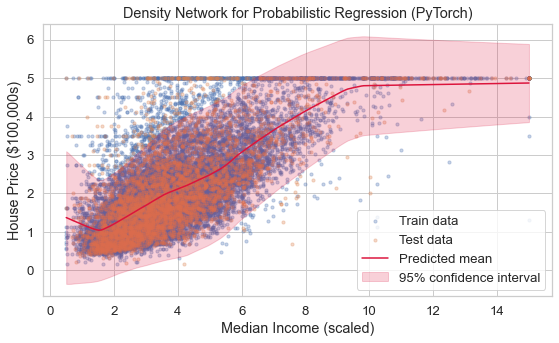

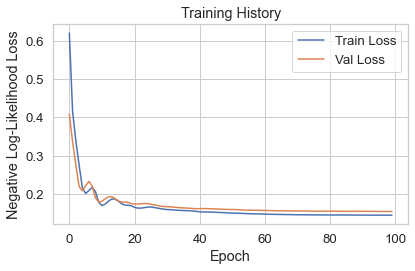

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Load and preprocess data
data = fetch_california_housing()
X = data.data
y = data.target

# For visualization, use only one feature (e.g., MedInc) for 1D regression
X = X[:, [0]]  # MedInc

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert to torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).unsqueeze(1)

# 2. Build a density network (outputting mean and log-variance)
class DensityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(64, 1)
        self.log_var_head = nn.Linear(64, 1)
    def forward(self, x):
        h = self.net(x)
        mean = self.mean_head(h)
        log_var = self.log_var_head(h)
        return mean, log_var

def nll_gaussian(y_true, mean, log_var):
    # Negative log-likelihood for Gaussian output
    precision = torch.exp(-log_var)
    return 0.5 * torch.mean(log_var + (y_true - mean) ** 2 * precision)

model = DensityNet()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. Train the model
train_losses = []
val_losses = []
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    mean, log_var = model(X_train_t)
    loss = nll_gaussian(y_train_t, mean, log_var)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation loss
    model.eval()
    with torch.no_grad():
        mean_val, log_var_val = model(X_test_t)
        val_loss = nll_gaussian(y_test_t, mean_val, log_var_val)
        val_losses.append(val_loss.item())

# 4. Predict and plot results
X_plot = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 200).reshape(-1, 1)
X_plot_t = torch.tensor(X_plot, dtype=torch.float32)
model.eval()
with torch.no_grad():
    mean_pred, log_var_pred = model(X_plot_t)
    mean_pred = mean_pred.squeeze().numpy()
    log_var_pred = log_var_pred.squeeze().numpy()
    std_pred = np.sqrt(np.exp(log_var_pred))

# Inverse transform to original scale
mean_pred_orig = scaler_y.inverse_transform(mean_pred.reshape(-1, 1)).flatten()
std_pred_orig = std_pred * scaler_y.scale_[0]
X_plot_orig = scaler_X.inverse_transform(X_plot).flatten()

# Plot predictions with 95% confidence interval
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=10, alpha=0.3, label='Train data')
plt.scatter(X_test, y_test, s=10, alpha=0.3, label='Test data')
plt.plot(X_plot_orig, mean_pred_orig, color='crimson', label='Predicted mean')
plt.fill_between(
    X_plot_orig,
    mean_pred_orig - 1.96 * std_pred_orig,
    mean_pred_orig + 1.96 * std_pred_orig,
    color='crimson', alpha=0.2, label='95% confidence interval'
)
plt.xlabel('Median Income (scaled)')
plt.ylabel('House Price ($100,000s)')
plt.title('Density Network for Probabilistic Regression (PyTorch)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood Loss')
plt.title('Training History')
plt.legend()
plt.tight_layout()
plt.show()

